# HW2_BayuFebriansyah

## Problem 2: Flight delays

In Homework 1, I used multiple linear regression to predict departure delay in minutes from information available before a flight. The first model used airline, distance, scheduled duration, and periodic terms for weekday and departure time. Its test RMSE was **53.39 minutes** and its test $R^2$ was **0.0152**. Replacing the daily time terms with time blocks and adding airport groups only improved these to **53.27 minutes** and **0.0195**. The model still struggled to predict individual delays.

Here I ask a simpler question: **will the flight depart at least 15 minutes late?** I set `DepDel15 = 1` when `DEP_DELAY >= 15`, and 0 otherwise. I still use only information available before departure.

My first classification run used a random sample of 20,000 flights, split into 16,000 training and 4,000 test flights:

| First approach | Test error | AUC |
| --- | ---: | ---: |
| KNN, K = 5 | 21.625% | 0.6230 |
| Logistic regression | 20.250% | 0.6605 |
| Always predict no delay | 20.150% | — |

These errors were close to, or worse than, always predicting no delay. I revised the approach by increasing the training sample, trying more K values and logistic regularization settings, and comparing time bins, routes, and airline-origin combinations. I use a separate validation set to choose these settings by AUC and then choose probability cutoffs that minimize validation error.


### Data

The CSV contains weekday, airline, origin, destination, scheduled departure time, scheduled duration, distance, and departure delay. All seven pre-departure fields are used; `DEP_DELAY` is used only to create the target. I convert scheduled HHMM to minutes after midnight and treat weekday and airport IDs as categories. The file has no date or month, so I cannot test future-month performance.

I drop missing values. Unlike HW1, this follows the agreed missing-only rule and retains one record with a negative scheduled duration, leaving 592,748 complete rows instead of 592,747. That record is a data-quality limitation.

`SAMPLE_SIZE` controls the training sample; set it to `None` to use the whole training pool. The validation and test samples stay fixed when only this setting changes. After selecting settings, I add the validation rows to the final training fit. Rerun all cells after changing the settings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Training rows, None uses the full training pool.
SAMPLE_SIZE = 100000

# Fixed holdout sizes and random seed.
VALIDATION_SIZE = 5000
TEST_SIZE = 5000
RANDOM_STATE = 42

# Candidate model settings.
K_VALUES = [1, 3, 5, 9, 15, 21, 31, 51, 101]

C_VALUES = [0.01, 0.1, 1.0, 10.0]

TIME_BIN_HOURS = 3

LEARNING_SIZES = [20000, 50000]

# Path relative to the HW2 repository.
CSV_PATH = "../../HW1/T_ONTIME_REPORTING.csv"

In [3]:
flights = pd.read_csv(CSV_PATH)

predictor_columns = [
    "DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID", "CRS_DEP_TIME", "CRS_ELAPSED_TIME", "DISTANCE"
]
clean_data = flights[predictor_columns + ["DEP_DELAY"]].dropna().copy()
clean_data["DepDel15"] = (clean_data["DEP_DELAY"] >= 15).astype(int)

# Exclude the earlier sample from the new test set.
old_sample = clean_data.sample(n=20000, random_state=42)
test_candidates = clean_data.drop(index=old_sample.index)

unused_candidates, test_data = train_test_split(
    test_candidates, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=test_candidates["DepDel15"]
)

development_data = clean_data.drop(index=test_data.index)
training_pool, validation_data = train_test_split(
    development_data, test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE, stratify=development_data["DepDel15"]
)

# Sample training rows without changing either holdout.
training_data = training_pool.copy()
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(training_data):
    training_data = training_data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

if len(training_data) < max(K_VALUES):
    raise ValueError("Increase SAMPLE_SIZE or reduce the largest K value.")

print("Original rows:", len(flights))
print("Rows removed for missing values:", len(flights) - len(clean_data))
print("Complete rows:", len(clean_data))
print("Training pool:", len(training_pool))
print("Training rows used:", len(training_data))
print("Validation rows:", len(validation_data))
print("Reserved final test rows:", len(test_data))
print("Training delayed fraction:", round(training_data["DepDel15"].mean(), 4))

Original rows: 597919
Rows removed for missing values: 5171
Complete rows: 592748
Training pool: 582748
Training rows used: 100000
Validation rows: 5000
Reserved final test rows: 5000
Training delayed fraction: 0.2007


I compare the original features with three-hour departure bins, route categories, airline-origin categories, and all three additions together. These are fixed combinations of information already in the CSV; they do not use delay outcomes. The time bins follow the step-function idea from the lectures. 

Numeric predictors are standardized using training data. Category columns also come from training data, an unseen category gets zeros in its dummy columns. Sparse storage saves memory without changing the feature values.

In [4]:
def add_features(table):
    table = table.copy()

    # Convert HHMM to minutes and make the candidate categories.
    hours = table["CRS_DEP_TIME"] // 100
    minutes = table["CRS_DEP_TIME"] % 100
    table["ScheduledDepartureMinutes"] = hours * 60 + minutes

    for column in ["DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID", "DEST_AIRPORT_ID"]:
        table[column] = table[column].astype(str)

    table["Route"] = table["ORIGIN_AIRPORT_ID"] + "_" + table["DEST_AIRPORT_ID"]
    table["AirlineOrigin"] = table["OP_UNIQUE_CARRIER"] + "_" + table["ORIGIN_AIRPORT_ID"]

    table["DepartureTimeBin"] = (table["ScheduledDepartureMinutes"] // (60 * TIME_BIN_HOURS)).astype(str)
    return table

training_data = add_features(training_data)
validation_data = add_features(validation_data)

numeric_columns = ["ScheduledDepartureMinutes", "CRS_ELAPSED_TIME", "DISTANCE"]
base_categories = ["DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID", "DEST_AIRPORT_ID"]

feature_sets = {
    "Baseline": [],
    "Time bins": ["DepartureTimeBin"],
    "Route": ["Route"],
    "Airline-origin": ["AirlineOrigin"],
    "All additions": ["DepartureTimeBin", "Route", "AirlineOrigin"]
}

y_train = training_data["DepDel15"]
y_validation = validation_data["DepDel15"]

def prepare_predictors(fitting_table, other_table, extra_categories):
    categories = base_categories + extra_categories
    columns = numeric_columns + categories
    fitting_X = fitting_table[columns].copy()
    other_X = other_table[columns].copy()

    # Learn scaling and category columns from fitting rows only.
    scaler = StandardScaler()
    fitting_X[numeric_columns] = scaler.fit_transform(fitting_X[numeric_columns])
    other_X[numeric_columns] = scaler.transform(other_X[numeric_columns])

    fitting_X = pd.get_dummies(fitting_X, columns=categories, dtype=float, sparse=True)
    other_X = pd.get_dummies(other_X, columns=categories, dtype=float, sparse=True)

    other_X = other_X.reindex(columns=fitting_X.columns, fill_value=0)

    # Use sparse storage for the full predictor table.
    fitting_X = fitting_X.astype(pd.SparseDtype("float64", 0.0))
    other_X = other_X.astype(pd.SparseDtype("float64", 0.0))
    return fitting_X, other_X, scaler

### Models

KNN uses equal votes and Euclidean distance, as in Problem 1. Its delay probability is the fraction of delayed flights among the K neighbors. I find the largest K once and reuse the first K neighbors for each smaller value. Equal-distance ordering follows the library's returned order.

Logistic regression estimates a delay probability. Smaller `C` means stronger L2 regularization. I select each model's features and K or C using the highest validation AUC, exact ties keep the first candidate.

Next, I choose the probability cutoff with the lowest validation error. A prediction is 1 when `probability > cutoff`; equality gives 0. I try the distinct validation probabilities plus 0, 0.5, and 1. Ties favor the cutoff closest to 0.5, then the smaller cutoff. The target remains a 15-minute delay regardless of this probability cutoff.

The last table in this section compares training sample sizes on the same validation flights, keeping the selected model settings fixed. It checks whether more training data helps. No test results are used to choose features, settings, or cutoffs.

In [5]:
knn_validation_rows = []
logistic_validation_rows = []
best_knn_auc = -1
best_logistic_auc = -1

for feature_name in feature_sets:
    print("Evaluating feature set:", feature_name, flush=True)
    extras = feature_sets[feature_name]
    train_X, validation_X, current_scaler = prepare_predictors(training_data, validation_data, extras)

    search_knn = KNeighborsClassifier(n_neighbors=max(K_VALUES), weights="uniform", metric="euclidean")
    search_knn.fit(train_X, y_train)

    # Reuse one neighbor search for all K values.
    neighbor_indices = search_knn.kneighbors(validation_X, return_distance=False)
    neighbor_labels = y_train.to_numpy()[neighbor_indices]

    for k in K_VALUES:
        probabilities = np.mean(neighbor_labels[:, :k], axis=1)
        auc = roc_auc_score(y_validation, probabilities)
        predictions = (probabilities > 0.5).astype(int)
        error = np.mean(predictions != y_validation)
        knn_validation_rows.append({"Features": feature_name, "K": k, "Validation AUC": auc, "Error at 0.5": error})

        if auc > best_knn_auc:
            best_knn_auc = auc
            best_knn_k = k
            best_knn_features = feature_name
            best_knn_validation_probabilities = probabilities.copy()

    # Compare logistic regularization strengths.
    for c in C_VALUES:
        current_logistic = LogisticRegression(C=c, max_iter=1000)
        current_logistic.fit(train_X, y_train)
        probabilities = current_logistic.predict_proba(validation_X)[:, 1]
        auc = roc_auc_score(y_validation, probabilities)
        predictions = (probabilities > 0.5).astype(int)
        error = np.mean(predictions != y_validation)
        logistic_validation_rows.append({"Features": feature_name, "C": c, "Validation AUC": auc, "Error at 0.5": error, "Iterations": current_logistic.n_iter_[0]})

        if auc > best_logistic_auc:
            best_logistic_auc = auc
            best_logistic_c = c
            best_logistic_features = feature_name
            best_logistic_validation_probabilities = probabilities.copy()

knn_validation_results = pd.DataFrame(knn_validation_rows)
logistic_validation_results = pd.DataFrame(logistic_validation_rows)
print("\nKNN validation results:")
print(knn_validation_results.round(5).to_string(index=False))
print("\nLogistic regression validation results:")
print(logistic_validation_results.round(5).to_string(index=False))
print("\nSelected KNN:", best_knn_features, "K =", best_knn_k)
print("Selected logistic regression:", best_logistic_features, "C =", best_logistic_c)

Evaluating feature set: Baseline
Evaluating feature set: Time bins
Evaluating feature set: Route
Evaluating feature set: Airline-origin
Evaluating feature set: All additions

KNN validation results:
      Features   K  Validation AUC  Error at 0.5
      Baseline   1         0.56525        0.2768
      Baseline   3         0.61791        0.2376
      Baseline   5         0.63377        0.2230
      Baseline   9         0.65965        0.2076
      Baseline  15         0.67248        0.2014
      Baseline  21         0.68403        0.1974
      Baseline  31         0.69218        0.2024
      Baseline  51         0.69648        0.2010
      Baseline 101         0.70109        0.1994
     Time bins   1         0.56712        0.2750
     Time bins   3         0.61404        0.2392
     Time bins   5         0.63596        0.2188
     Time bins   9         0.65592        0.2108
     Time bins  15         0.67160        0.2028
     Time bins  21         0.67532        0.2012
     Time bins  3

In [6]:
# Choose the cutoff with the fewest validation mistakes.
def choose_cutoff(labels, probabilities):
    cutoffs = np.unique(np.append(probabilities, [0.0, 0.5, 1.0]))
    best_error = 1.0
    best_cutoff = 0.5

    for cutoff in cutoffs:
        predictions = (probabilities > cutoff).astype(int)
        error = np.mean(predictions != labels)

        if error < best_error:
            best_error = error
            best_cutoff = cutoff
        elif error == best_error and abs(cutoff - 0.5) < abs(best_cutoff - 0.5):
            best_cutoff = cutoff

    return best_cutoff, best_error

knn_cutoff, knn_validation_error = choose_cutoff(y_validation, best_knn_validation_probabilities)
logistic_cutoff, logistic_validation_error = choose_cutoff(y_validation, best_logistic_validation_probabilities)

print("KNN selected cutoff:", round(knn_cutoff, 6))
print("KNN validation error at selected cutoff:", round(knn_validation_error, 5))
print("Logistic regression selected cutoff:", round(logistic_cutoff, 6))
print("Logistic regression validation error at selected cutoff:", round(logistic_validation_error, 5))
print("Always-class-0 validation error:", round(y_validation.mean(), 5))

KNN selected cutoff: 0.465347
KNN validation error at selected cutoff: 0.199
Logistic regression selected cutoff: 0.53884
Logistic regression validation error at selected cutoff: 0.1998
Always-class-0 validation error: 0.2016


In [7]:
learning_rows = [
    {"Training rows": len(training_data), "Model": "KNN", "Validation AUC": best_knn_auc},
    {"Training rows": len(training_data), "Model": "Logistic regression", "Validation AUC": best_logistic_auc}
]

# Compare smaller training samples using the same validation rows.
for size in LEARNING_SIZES:
    if size >= len(training_data) or size < max(K_VALUES):
        continue

    smaller_training = training_data.sample(n=size, random_state=RANDOM_STATE)
    smaller_y = smaller_training["DepDel15"]

    small_X, validation_X, small_scaler = prepare_predictors(
        smaller_training, validation_data, feature_sets[best_knn_features]
    )
    small_knn = KNeighborsClassifier(n_neighbors=best_knn_k, weights="uniform", metric="euclidean")
    small_knn.fit(small_X, smaller_y)
    indices = small_knn.kneighbors(validation_X, n_neighbors=max(K_VALUES), return_distance=False)
    labels = smaller_y.to_numpy()[indices]
    probabilities = np.mean(labels[:, :best_knn_k], axis=1)
    learning_rows.append({"Training rows": size, "Model": "KNN", "Validation AUC": roc_auc_score(y_validation, probabilities)})

    small_X, validation_X, small_scaler = prepare_predictors(
        smaller_training, validation_data, feature_sets[best_logistic_features]
    )
    small_logistic = LogisticRegression(C=best_logistic_c, max_iter=1000)
    small_logistic.fit(small_X, smaller_y)
    probabilities = small_logistic.predict_proba(validation_X)[:, 1]
    learning_rows.append({"Training rows": size, "Model": "Logistic regression", "Validation AUC": roc_auc_score(y_validation, probabilities)})

learning_results = pd.DataFrame(learning_rows).sort_values(["Training rows", "Model"])
print(learning_results.round(5).to_string(index=False))

 Training rows               Model  Validation AUC
         20000                 KNN         0.68245
         20000 Logistic regression         0.68850
         50000                 KNN         0.69299
         50000 Logistic regression         0.69267
        100000                 KNN         0.70109
        100000 Logistic regression         0.69581


### Results

All choices are fixed before using the test predictions. I refit on the selected training sample plus the validation rows and keep the cutoffs unchanged. For comparison, the original KNN (`K=5`) and logistic (`C=1`) settings are fitted on those same rows.

I report test error, AUC, precision, and recall. AUC uses the probabilities, while the other metrics use the chosen 0/1 predictions. For binary predictions, squared error is 1 for a mistake and 0 for a correct answer, so **test MSE equals test error**.

The required MSE-versus-K plot uses a fixed cutoff of 0.5 and the validation-selected feature set. I use it to describe the results, not to change the selected K.

In [8]:
# Lock choices before preparing or evaluating test predictors.
locked_choices = {
    "KNN features": best_knn_features,
    "KNN K": best_knn_k,
    "KNN cutoff": float(knn_cutoff),
    "Logistic features": best_logistic_features,
    "Logistic C": best_logistic_c,
    "Logistic cutoff": float(logistic_cutoff)
}
print("Locked choices:", locked_choices)

final_training = pd.concat([training_data, validation_data])
y_final_training = final_training["DepDel15"]
test_data = add_features(test_data)
y_test = test_data["DepDel15"]
print("Final fitting rows:", len(final_training))
print("Final test rows:", len(test_data))

knn_X, knn_test_X, final_knn_scaler = prepare_predictors(
    final_training, test_data, feature_sets[best_knn_features]
)
final_knn = KNeighborsClassifier(n_neighbors=best_knn_k, weights="uniform", metric="euclidean")
final_knn.fit(knn_X, y_final_training)
test_neighbor_indices = final_knn.kneighbors(knn_test_X, n_neighbors=max(K_VALUES), return_distance=False)
test_neighbor_labels = y_final_training.to_numpy()[test_neighbor_indices]
knn_test_probabilities = np.mean(test_neighbor_labels[:, :best_knn_k], axis=1)

logistic_X, logistic_test_X, final_logistic_scaler = prepare_predictors(
    final_training, test_data, feature_sets[best_logistic_features]
)
final_logistic = LogisticRegression(C=best_logistic_c, max_iter=1000)
final_logistic.fit(logistic_X, y_final_training)
logistic_test_probabilities = final_logistic.predict_proba(logistic_test_X)[:, 1]

# Refit the original settings on the same rows for comparison.
baseline_X, baseline_test_X, baseline_scaler = prepare_predictors(final_training, test_data, [])
baseline_knn = KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="euclidean")
baseline_knn.fit(baseline_X, y_final_training)
baseline_indices = baseline_knn.kneighbors(baseline_test_X, n_neighbors=max(K_VALUES), return_distance=False)
baseline_labels = y_final_training.to_numpy()[baseline_indices]
baseline_knn_probabilities = np.mean(baseline_labels[:, :5], axis=1)

baseline_logistic = LogisticRegression(C=1.0, max_iter=1000)
baseline_logistic.fit(baseline_X, y_final_training)
baseline_logistic_probabilities = baseline_logistic.predict_proba(baseline_test_X)[:, 1]

Locked choices: {'KNN features': 'Baseline', 'KNN K': 101, 'KNN cutoff': 0.46534653465346537, 'Logistic features': 'All additions', 'Logistic C': 0.1, 'Logistic cutoff': 0.5388395845474903}
Final fitting rows: 105000
Final test rows: 5000


In [9]:
evaluations = [
    ("Baseline KNN (K=5)", baseline_knn_probabilities, 0.5),
    ("Tuned KNN, cutoff 0.5", knn_test_probabilities, 0.5),
    ("Tuned KNN, selected cutoff", knn_test_probabilities, knn_cutoff),
    ("Baseline logistic (C=1)", baseline_logistic_probabilities, 0.5),
    ("Tuned logistic, cutoff 0.5", logistic_test_probabilities, 0.5),
    ("Tuned logistic, selected cutoff", logistic_test_probabilities, logistic_cutoff)
]

test_rows = []
for name, probabilities, cutoff in evaluations:
    predictions = (probabilities > cutoff).astype(int)
    test_rows.append({
        "Model": name,
        "Cutoff": cutoff,
        "Test error": np.mean(predictions != y_test),
        "Test MSE": mean_squared_error(y_test, predictions),
        "AUC": roc_auc_score(y_test, probabilities),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0)
    })

test_results = pd.DataFrame(test_rows)
print(test_results.round(5).to_string(index=False))
print("\nAlways-class-0 test error:", round(y_test.mean(), 5))

# Confusion matrices: true classes in rows, predicted classes in columns.
knn_test_predictions = (knn_test_probabilities > knn_cutoff).astype(int)
logistic_test_predictions = (logistic_test_probabilities > logistic_cutoff).astype(int)
print("\nTuned KNN confusion matrix (class order 0, 1):")
print(confusion_matrix(y_test, knn_test_predictions, labels=[0, 1]))
print("Tuned logistic confusion matrix (class order 0, 1):")
print(confusion_matrix(y_test, logistic_test_predictions, labels=[0, 1]))

                          Model  Cutoff  Test error  Test MSE     AUC  Precision  Recall
             Baseline KNN (K=5) 0.50000      0.2306    0.2306 0.61879    0.34737 0.16369
          Tuned KNN, cutoff 0.5 0.50000      0.1988    0.1988 0.70135    0.58537 0.04762
     Tuned KNN, selected cutoff 0.46535      0.1966    0.1966 0.70135    0.59259 0.07937
        Baseline logistic (C=1) 0.50000      0.2010    0.2010 0.67466    0.52308 0.03373
     Tuned logistic, cutoff 0.5 0.50000      0.2024    0.2024 0.68878    0.46970 0.03075
Tuned logistic, selected cutoff 0.53884      0.2022    0.2022 0.68878    0.45161 0.01389

Always-class-0 test error: 0.2016

Tuned KNN confusion matrix (class order 0, 1):
[[3937   55]
 [ 928   80]]
Tuned logistic confusion matrix (class order 0, 1):
[[3975   17]
 [ 994   14]]


  K  Test MSE at cutoff 0.5
  1                  0.2916
  3                  0.2482
  5                  0.2306
  9                  0.2140
 15                  0.2052
 21                  0.2024
 31                  0.1996
 51                  0.2002
101                  0.1988


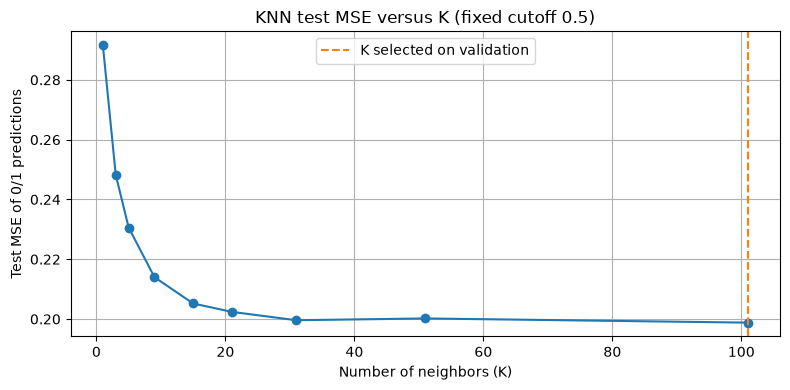

In [10]:
knn_mse_values = []
for k in K_VALUES:
    probabilities = np.mean(test_neighbor_labels[:, :k], axis=1)
    predictions = (probabilities > 0.5).astype(int)
    mse = mean_squared_error(y_test, predictions)
    knn_mse_values.append(mse)

knn_mse_results = pd.DataFrame({"K": K_VALUES, "Test MSE at cutoff 0.5": knn_mse_values})
print(knn_mse_results.round(5).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(K_VALUES, knn_mse_values, marker="o")
plt.axvline(best_knn_k, color="tab:orange", linestyle="--", label="K selected on validation")
plt.xlabel("Number of neighbors (K)")
plt.ylabel("Test MSE of 0/1 predictions")
plt.title("KNN test MSE versus K (fixed cutoff 0.5)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Summarize the current run; these values update when settings change.
knn_result = test_results.loc[test_results["Model"] == "Tuned KNN, selected cutoff"].iloc[0]
logistic_result = test_results.loc[test_results["Model"] == "Tuned logistic, selected cutoff"].iloc[0]
knn_baseline = test_results.loc[test_results["Model"] == "Baseline KNN (K=5)"].iloc[0]
logistic_baseline = test_results.loc[test_results["Model"] == "Baseline logistic (C=1)"].iloc[0]

print(f"I used {len(training_data):,} training flights and {len(validation_data):,} validation flights.")
print(f"The final fit used {len(final_training):,} flights, with {len(test_data):,} separate test flights.")
print(f"Validation selected K={best_knn_k} with {best_knn_features.lower()} features for KNN,")
print(f"and C={best_logistic_c} with {best_logistic_features.lower()} for logistic regression.")
print(f"The selected cutoffs were {knn_cutoff:.4f} and {logistic_cutoff:.4f}, respectively.")

for name, result, baseline in [
    ("KNN", knn_result, knn_baseline),
    ("Logistic regression", logistic_result, logistic_baseline)
]:
    print(f"\n{name}: test error was {result['Test error']:.2%}, compared with {baseline['Test error']:.2%} for its original settings.")
    print(f"AUC was {result['AUC']:.4f}, compared with {baseline['AUC']:.4f}.")
    print(f"It detected {result['Recall']:.2%} of delayed flights.")
    if result["Test error"] < y_test.mean():
        print("Its error was lower than always predicting no delay.")
    else:
        print("Its error did not beat always predicting no delay.")

print(f"\nAlways predicting no delay gave {y_test.mean():.2%} test error.")
print(f"At cutoff 0.5, KNN test MSE changed from {knn_mse_values[0]:.4f} at K={K_VALUES[0]}")
print(f"to {knn_mse_values[-1]:.4f} at K={K_VALUES[-1]}; the full pattern is shown above.")
if best_knn_k == max(K_VALUES):
    print("The selected K is the largest one I tried, so this does not establish the best possible K.")

print("\nValidation AUC as I increased the training sample:")
for name in ["KNN", "Logistic regression"]:
    rows = learning_results.loc[learning_results["Model"] == name].sort_values("Training rows")
    first = rows.iloc[0]
    last = rows.iloc[-1]
    print(f"{name}: {first['Validation AUC']:.4f} with {int(first['Training rows']):,} rows")
    print(f"to {last['Validation AUC']:.4f} with {int(last['Training rows']):,} rows.")

I used 100,000 training flights and 5,000 validation flights.
The final fit used 105,000 flights, with 5,000 separate test flights.
Validation selected K=101 with baseline features for KNN,
and C=0.1 with all additions for logistic regression.
The selected cutoffs were 0.4653 and 0.5388, respectively.

KNN: test error was 19.66%, compared with 23.06% for its original settings.
AUC was 0.7014, compared with 0.6188.
It detected 7.94% of delayed flights.
Its error was lower than always predicting no delay.

Logistic regression: test error was 20.22%, compared with 20.10% for its original settings.
AUC was 0.6888, compared with 0.6747.
It detected 1.39% of delayed flights.
Its error did not beat always predicting no delay.

Always predicting no delay gave 20.16% test error.
At cutoff 0.5, KNN test MSE changed from 0.2916 at K=1
to 0.1988 at K=101; the full pattern is shown above.
The selected K is the largest one I tried, so this does not establish the best possible K.

Validation AUC as I

The error rate needs to be read alongside recall. About one in five test flights was delayed, so a model can have a fairly low error while missing most delayed flights. Minimizing validation error did not require a minimum recall. AUC measures how well the model ranks flights by delay risk; better AUC does not guarantee fewer mistakes at a particular cutoff.

The saved run improves KNN's error, but the improvement over always predicting no delay is small. Logistic regression improves AUC while slightly worsening error relative to its original settings. I would not describe either model as a reliable warning system for passengers yet.

The results apply to this random split of the supplied CSV. They do not establish future-month performance, and missing-delay records are excluded. Larger samples also make KNN slower. The tables and printed discussion above update when the settings change, these observations describe the saved 100,000-row training run.


## Problem 3: LDA and QDA

I use one predictor, $p=1$. Let $\pi_k=P(Y=k)>0$ be the prior probability of class $k$, and let $f_k(x)$ be the conditional density of $X$ in that class. Assume positive variances. The starting formulas are obtained from lecture 5.

### LDA

Bayes' rule gives

$$
P(Y=k\mid X=x)=\frac{\pi_k f_k(x)}
{\sum_{\ell=1}^{K}\pi_\ell f_\ell(x)}.
$$

For a fixed $x$, the denominator is positive and is the same for every class. Removing it does not change which class has the largest value. Taking the logarithm also preserves the order, so

$$
\underset{k}{\arg\max}\ P(Y=k\mid X=x)
=\underset{k}{\arg\max}\ \pi_k f_k(x)
=\underset{k}{\arg\max}\ \bigl[\log\pi_k+\log f_k(x)\bigr].
$$

For LDA, the Gaussian class densities have the same variance $\sigma^2$:

$$
f_k(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[-\frac{(x-\mu_k)^2}{2\sigma^2}\right].
$$

Substituting this density and expanding the square gives

$$
\begin{aligned}
\log\pi_k+\log f_k(x)
&=\log\pi_k-\frac12\log(2\pi\sigma^2)
-\frac{x^2-2x\mu_k+\mu_k^2}{2\sigma^2}\\
&=\underbrace{-\frac12\log(2\pi\sigma^2)
-\frac{x^2}{2\sigma^2}}_{\text{same for every class}}
+\frac{x\mu_k}{\sigma^2}
-\frac{\mu_k^2}{2\sigma^2}+\log\pi_k.
\end{aligned}
$$

The terms marked above do not depend on $k$, so I can remove them when comparing classes. The remaining expression is the lecture's LDA discriminant:

$$
\boxed{\delta_k^{\mathrm{LDA}}(x)
=\frac{x\mu_k}{\sigma^2}
-\frac{\mu_k^2}{2\sigma^2}+\log\pi_k.}
$$

Therefore,

$$
\boxed{\underset{k}{\arg\max}\ P(Y=k\mid X=x)
=\underset{k}{\arg\max}\ \delta_k^{\mathrm{LDA}}(x).}
$$

Both rules choose the same class, with the same tied classes if there is a tie. The discriminant is linear in $x$. Replacing the parameters with their estimates gives the fitted rule from the lecture.

### QDA

Now let each class have its own variance $\sigma_k^2$. The Gaussian density becomes

$$
f_k(x)=\frac{1}{\sqrt{2\pi\sigma_k^2}}
\exp\left[-\frac{(x-\mu_k)^2}{2\sigma_k^2}\right].
$$

The same Bayes-and-log argument still applies:

$$
\log\pi_k+\log f_k(x)
=\log\pi_k-\frac12\log(2\pi)
-\frac12\log\sigma_k^2-\frac{(x-\mu_k)^2}{2\sigma_k^2}.
$$

Only $-\tfrac12\log(2\pi)$ is common to all classes here. In particular, I must keep the variance term from the Gaussian normalizing factor. Removing the common constant gives

$$
\delta_k^{\mathrm{QDA}}(x)
=-\frac12\log\sigma_k^2
-\frac{(x-\mu_k)^2}{2\sigma_k^2}+\log\pi_k.
$$

Expanding again,

$$
\boxed{\delta_k^{\mathrm{QDA}}(x)
=-\frac{x^2}{2\sigma_k^2}
+\frac{\mu_k}{\sigma_k^2}x
-\frac{\mu_k^2}{2\sigma_k^2}
-\frac12\log\sigma_k^2+\log\pi_k.}
$$

This has the form $a_kx^2+b_kx+c_k$. Unlike LDA, the coefficient of $x^2$ depends on the class, so the quadratic term cannot be removed from every discriminant at once. For two classes $k$ and $\ell$, the coefficient of $x^2$ in $\delta_k(x)-\delta_\ell(x)$ is

$$
\frac{1}{2\sigma_\ell^2}-\frac{1}{2\sigma_k^2}.
$$

It is nonzero when their variances differ. Their equal-score equation is therefore quadratic in $x$, which gives QDA its name. This agrees with the one-predictor version of the QDA formula.

As a check, setting every $\sigma_k^2=\sigma^2$ makes the quadratic and log-variance terms common to all classes. Dropping them recovers the LDA discriminant above.